In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
features = pd.read_parquet('data/diabetes_features.parquet')
target = pd.read_parquet('data/diabetes_target.parquet')

# Creating a first encounter mask
first_encounter_mask = features['encounter_id'] == features.loc[:, ['patient_nbr', 'encounter_id']].groupby('patient_nbr').transform(np.min)['encounter_id']

# Creating features and a target for only the first encounters
first_encounter_features = features[first_encounter_mask]
first_encounter_target = target[first_encounter_mask]

# Splitting train and test
X_train, X_test, y_train, y_test = train_test_split(first_encounter_features, first_encounter_target, test_size=0.2, random_state=42)

In [3]:
# Creating a dataframe to inspect the split
split_inspection_df = features.loc[:, ['patient_nbr', 'encounter_id']].copy()

# Adding the target to the inspection df
split_inspection_df['target'] = target
split_inspection_df['first_encounter_mask'] = first_encounter_mask

# Creating a second dataframe for post split
split_inspection_2 = first_encounter_features.loc[:, ['patient_nbr', 'encounter_id']].copy()
split_inspection_2['target'] = first_encounter_target

# Checking that all targets match
(split_inspection_df[split_inspection_df.first_encounter_mask == True]['target'] == split_inspection_2['target']).astype(int).mean()

np.float64(1.0)

# Columns and Data Types

In [4]:
print(features.info())

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  int64   
 1   patient_nbr               101766 non-null  int64   
 2   race                      101766 non-null  category
 3   gender                    101766 non-null  category
 4   age                       101766 non-null  category
 5   weight                    101766 non-null  category
 6   admission_type_id         101766 non-null  int64   
 7   discharge_disposition_id  101766 non-null  int64   
 8   admission_source_id       101766 non-null  int64   
 9   time_in_hospital          101766 non-null  int64   
 10  payer_code                101766 non-null  category
 11  medical_specialty         101766 non-null  category
 12  num_lab_procedures        101766 non-null  int64   
 13  num_procedures            101766 non-nul

In [5]:
for c in features.columns.values:
    print(c)

encounter_id
patient_nbr
race
gender
age
weight
admission_type_id
discharge_disposition_id
admission_source_id
time_in_hospital
payer_code
medical_specialty
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
diag_1
diag_2
diag_3
number_diagnoses
max_glu_serum
A1Cresult
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide.metformin
glipizide.metformin
glimepiride.pioglitazone
metformin.rosiglitazone
metformin.pioglitazone
change
diabetesMed


In [6]:
target

,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO
...,...
101761,>30
101762,NO
101763,NO
101764,NO


In [7]:
# Exploring a single patient
features[features.patient_nbr == 88785891]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed
38307,119039172,88785891,Caucasian,Female,[20-30),?,1,1,7,1,...,No,No,Up,No,No,No,No,No,Ch,Yes
40252,125094312,88785891,Caucasian,Female,[20-30),?,1,1,7,1,...,No,No,Down,No,No,No,No,No,Ch,Yes
40661,126171582,88785891,Caucasian,Female,[20-30),?,1,1,7,5,...,No,No,Up,No,No,No,No,No,Ch,Yes
44515,137245596,88785891,Caucasian,Female,[20-30),?,3,1,7,2,...,No,No,Up,No,No,No,No,No,Ch,Yes
45147,139425576,88785891,Caucasian,Female,[20-30),?,1,1,7,2,...,No,No,Up,No,No,No,No,No,Ch,Yes
45986,141994242,88785891,Caucasian,Female,[20-30),?,2,1,7,4,...,No,No,Up,No,No,No,No,No,Ch,Yes
50167,150986298,88785891,Caucasian,Female,[20-30),?,2,1,7,1,...,No,No,Up,No,No,No,No,No,Ch,Yes
50393,151413846,88785891,Caucasian,Female,[20-30),?,1,1,7,4,...,No,No,Up,No,No,No,No,No,Ch,Yes
50773,152188656,88785891,Caucasian,Female,[20-30),?,2,7,7,1,...,No,No,Up,No,No,No,No,No,Ch,Yes
51519,153558456,88785891,Caucasian,Female,[20-30),?,2,1,7,1,...,No,No,Up,No,No,No,No,No,Ch,Yes


# Missing Data

#### Key Findings

- Weight is missing for an entire patient, except for 36 patients captured below
- Missing values are encoded in some columns using "?" and None

In [8]:
# Diagnosing if weight is always missing for a patient
weight_diagnostic = features.loc[:, ['patient_nbr', 'weight']]

weight_diagnostic['missing_weight'] = weight_diagnostic['weight'].apply(lambda x: 1 if x == "?" else 0)

# Group and aggregate
grouped = weight_diagnostic.groupby('patient_nbr').agg({
    'missing_weight': 'sum',  # count of missing weights
    'weight': 'count'          # total records for that patient
})

# Patients where missing_weight == total records are always missing
grouped['always_missing'] = grouped['missing_weight'] == grouped['weight']

grouped[(grouped["missing_weight"] != grouped['weight']) & (grouped["missing_weight"] > 0)]

,missing_weight,weight,always_missing
patient_nbr,,,
1743804,1,2,False
3515238,1,2,False
4019499,1,2,False
4790016,1,8,False
6316542,1,2,False
7994817,1,2,False
21684645,1,2,False
30775878,1,2,False
35879364,1,2,False


In [9]:
# Inspecting one patient that has mixed missing data
X_train[X_train.patient_nbr == 4790016]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed


### Diving into the use of Identifiers ("?", None) for missing data

In [10]:
qmark_missing = (features == "?").sum()
print(qmark_missing[qmark_missing > 0])

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64


In [11]:
none_missing = (features == "None").sum()
print(none_missing[none_missing > 0])

max_glu_serum    96420
A1Cresult        84748
dtype: int64


#### Correlation of Missing Values

In [12]:
((X_train == "?") | (X_train == "None")).astype(int).corr().round(4)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed
encounter_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_nbr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,NaN,NaN,1.0000,NaN,NaN,-0.0225,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,NaN,NaN,-0.0225,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discharge_disposition_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_source_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_in_hospital,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Exploring Patterns in Missing Data

Missing data in the following columns depends on admission type and admission source:

- max_glu_serum
- A1Cresult
- weight
- payer_code
- medical_specialty

This pattern is consistent with MAR with dependency on the admission source and type. Options for resolving this are:
- Stratify and fill --> impractical due to the missiness rate (80+%) and some groups not having values
- Flag missingess of the data --> challenge will be the flags will be highly correlated with admission type and source
- Drop columns --> straightforward, but there is information in the fact it was collected
- Filter --> impractical for features with a high missingness rate

My preferred imputation strategy per column is as follows:
- max_glu_serum, A1Cresult, weight, payer_code, medical_specialty --> flag but sanity check correlation with admission cols + conduct feature importance (admission type and source may fully account for this phenomenon in the model)
- race --> impute
- diag_1, diag_2, diag_3 --> drop

In [13]:
# Admission Type Crosstab Across Key Variables
for f in ['max_glu_serum', 'A1Cresult', 'weight', 'payer_code', 'medical_specialty']:
    ct = pd.crosstab(features['admission_type_id'], features[f])
    print(pd.DataFrame(ct.apply(lambda x: x / sum(x), axis=1)))


max_glu_serum          >200      >300      None      Norm
admission_type_id                                        
1                  0.002704  0.006186  0.984182  0.006927
2                  0.002652  0.002110  0.988366  0.006872
3                  0.000053  0.000318  0.998781  0.000848
4                  0.000000  0.000000  1.000000  0.000000
5                  0.173250  0.116405  0.422571  0.287774
6                  0.086940  0.061992  0.718201  0.132867
7                  0.000000  0.000000  1.000000  0.000000
8                  0.000000  0.000000  1.000000  0.000000
A1Cresult                >7        >8      None      Norm
admission_type_id                                        
1                  0.040415  0.093073  0.807964  0.058548
2                  0.044048  0.077597  0.827219  0.051136
3                  0.025704  0.045736  0.897557  0.031003
4                  0.200000  0.000000  0.800000  0.000000
5                  0.026332  0.047022  0.907001  0.019645
6             

In [14]:
# Admission Source Crosstab Across Key Variables
for f in ['max_glu_serum', 'A1Cresult', 'weight', 'payer_code', 'medical_specialty']:
    ct = pd.crosstab(features['admission_source_id'], features[f])
    print(ct.apply(lambda x: x / sum(x), axis=1))

max_glu_serum            >200      >300      None      Norm
admission_source_id                                        
1                    0.001657  0.001421  0.992559  0.004363
2                    0.006341  0.001812  0.980978  0.010870
3                    0.000000  0.000000  1.000000  0.000000
4                    0.000000  0.000314  0.999686  0.000000
5                    0.000000  0.000000  1.000000  0.000000
6                    0.000000  0.000000  1.000000  0.000000
7                    0.005079  0.008418  0.978833  0.007670
8                    0.000000  0.000000  1.000000  0.000000
9                    0.000000  0.000000  1.000000  0.000000
10                   0.000000  0.000000  1.000000  0.000000
11                   0.000000  0.000000  1.000000  0.000000
13                   0.000000  0.000000  1.000000  0.000000
14                   0.000000  0.000000  1.000000  0.000000
17                   0.167674  0.108391  0.426781  0.297154
20                   0.000000  0.000000 

In [15]:
# inspecting the specific crosstab of admission source and medical specialty
pd.crosstab(features['admission_source_id'], features['medical_specialty']).apply(lambda x: x / sum(x), axis=1)

medical_specialty,?,AllergyandImmunology,Anesthesiology,Anesthesiology-Pediatric,Cardiology,Dentistry,Emergency/Trauma,Endocrinology,Family/GeneralPractice,Gastroenterology,...,Radiologist,Speech,SportsMedicine,SurgicalSpecialty,Cardiology-Pediatric,Perinatology,Neurophysiology,DCPTEAM,Endocrinology-Metabolism,Resident
admission_source_id,,,,,,,,,,,,,,,,,,,,,
1,0.394081,0.000034,0.000304,0.000169,0.083477,0.000068,0.012582,0.001319,0.061086,0.011128,...,0.031558,0.000000,0.000034,0.001049,0.000169,0.000034,0.000034,0.000135,0.000034,0.000000
2,0.830616,0.000000,0.000000,0.000000,0.006341,0.000000,0.006341,0.000000,0.030797,0.007246,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.759358,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.529024,0.000000,0.000314,0.000941,0.112331,0.000000,0.001883,0.000628,0.028553,0.002196,...,0.032633,0.000000,0.000000,0.000000,0.000314,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.408187,0.000000,0.000000,0.000000,0.031579,0.000000,0.049123,0.000000,0.084211,0.003509,...,0.002339,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.188604,0.000000,0.000000,0.000000,0.028710,0.000000,0.015901,0.004859,0.163428,0.001325,...,0.001767,0.000000,0.000000,0.000442,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.558128,0.000104,0.000035,0.000191,0.027412,0.000035,0.123404,0.001165,0.060615,0.003044,...,0.001687,0.000017,0.000000,0.000017,0.000017,0.000000,0.000000,0.000035,0.000122,0.000035
8,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.062500,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.048000,0.000000,0.000000,0.000000,0.008000,0.000000,0.008000,0.008000,0.192000,0.016000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Exploring Categorical Values for Encoding Strategies

Columns for One-Hot Encoding:
- Race
- Gender
- change
- diabetesMed --> binary flag if a patient is taking any of the diabetes meds listed in the dataframe

Columns for Ordinal Encoding:
- Age
- metformin
- insulin

The following columns are highly sparse and will not be included in the training dataset:
- repaglinide
- nateglinide 
- chlorprpamide
- glimepiride
- acetohexamide
- glipizide
- glyburide
- tolbutamide
- pioglitazone
- rosiglitazone
- acarbose 
- miglitol 
- troglitazone 
- tolazamide 
- examide
- citoglipton 
- glyburide.metformin 
- glipizide.metformin 
- glimepiride.pioglitazone
- metformin.rosiglitazone 
- metformin.pioglitazone


In [16]:
features.select_dtypes(include=['object', 'category']).head(n=20)

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,examide,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),?,?,Pediatrics-Endocrinology,250.83,?,?,None,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),?,?,?,276,250.01,255,None,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),?,?,?,648,250,V27,None,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),?,?,?,8,250.43,403,None,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),?,?,?,197,157,250,None,...,No,No,Steady,No,No,No,No,No,Ch,Yes
5,Caucasian,Male,[50-60),?,?,?,414,411,250,None,...,No,No,Steady,No,No,No,No,No,No,Yes
6,Caucasian,Male,[60-70),?,?,?,414,411,V45,None,...,No,No,Steady,No,No,No,No,No,Ch,Yes
7,Caucasian,Male,[70-80),?,?,?,428,492,250,None,...,No,No,No,No,No,No,No,No,No,Yes
8,Caucasian,Female,[80-90),?,?,?,398,427,38,None,...,No,No,Steady,No,No,No,No,No,Ch,Yes
9,Caucasian,Female,[90-100),?,?,InternalMedicine,434,198,486,None,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [17]:
for c in features.select_dtypes(include=['object', 'category']).columns.to_list():
    print(f"Value counts for {c}:")
    print(features[c].value_counts())
    print("\n")

Value counts for race:
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


Value counts for gender:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


Value counts for age:
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64


Value counts for weight:
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64


Value counts for payer_code:
payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM 

# Outliers

Observations:
- num_lab_procedures has a concentration of observations at a few key values creating "spikiness". Most of this is occuring in admission type ID 1
- number_diagnoses appears to be truncated with a maximum of 9

No additional columns suggest an issue with outliers that can't be solved with scaling. Including admission_type_id should accoutn for the spikiness of lab procedures.

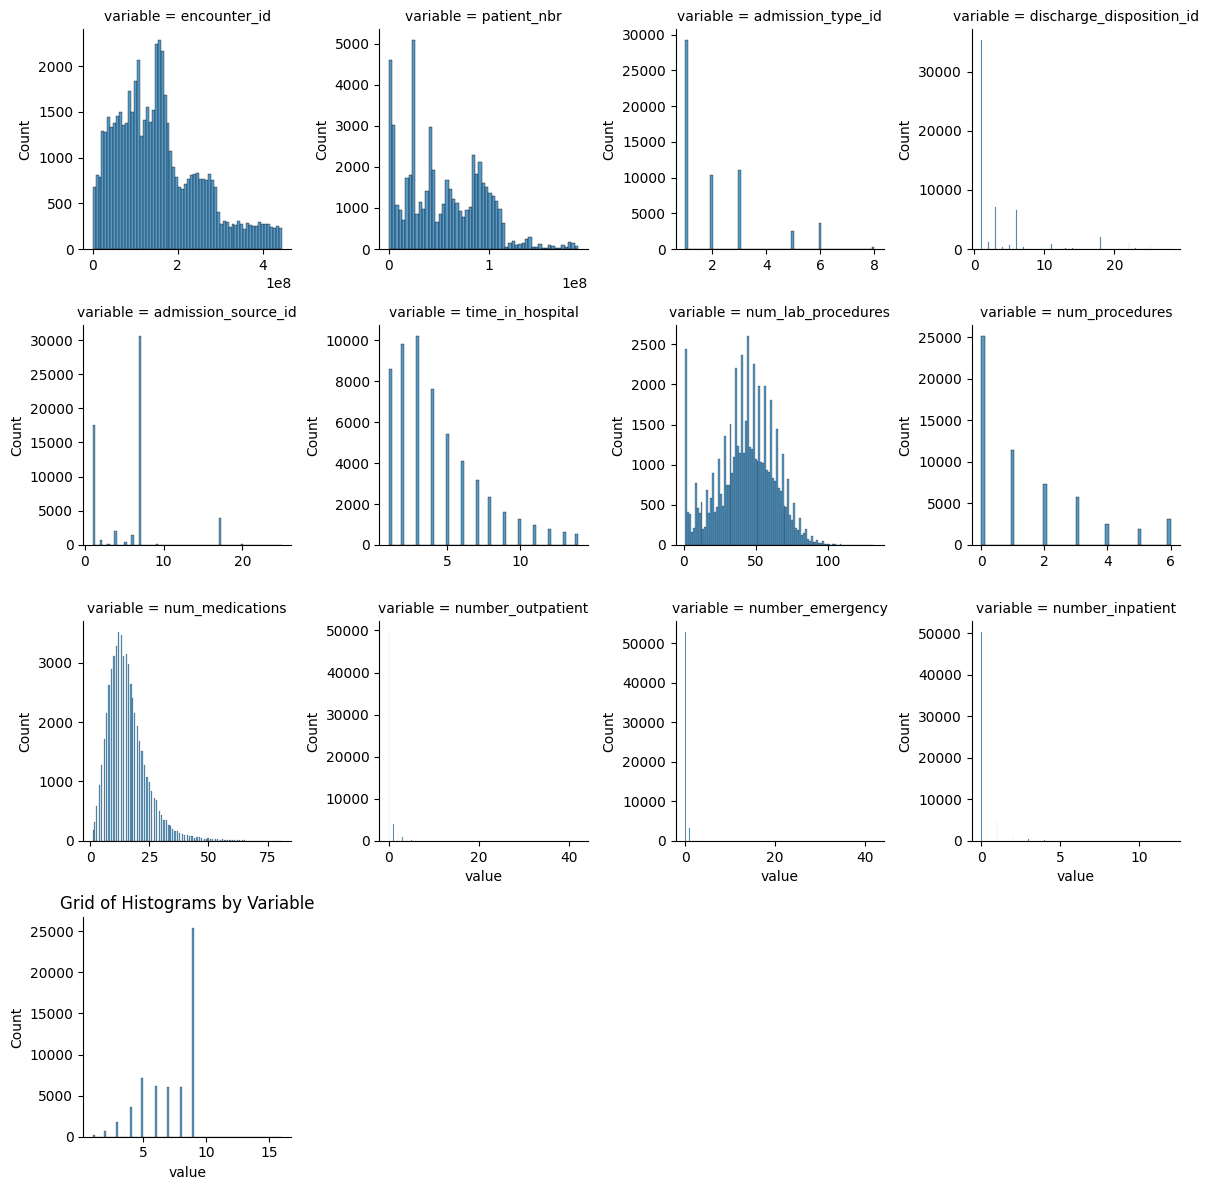

In [18]:
# Grabbing and melting a dataframe of numeric columns
numeric_cols = X_train.select_dtypes("number")
long_numeric = numeric_cols.melt()

# Plotting a grid of histograms for the numeric columns
grid = sns.FacetGrid(long_numeric, col='variable', col_wrap=4, sharex=False, sharey=False)
grid.map_dataframe(sns.histplot, x='value')
plt.title("Grid of Histograms by Variable")
plt.show()

In [19]:
# Inspecting the total number of observations by count of lab procedures
numeric_cols['num_lab_procedures'].value_counts().reset_index().sort_values("num_lab_procedures")

,num_lab_procedures,count
0,1,1818
41,2,623
57,3,415
71,4,223
79,5,165
...,...,...
111,114,1
113,118,1
109,120,1
115,121,1


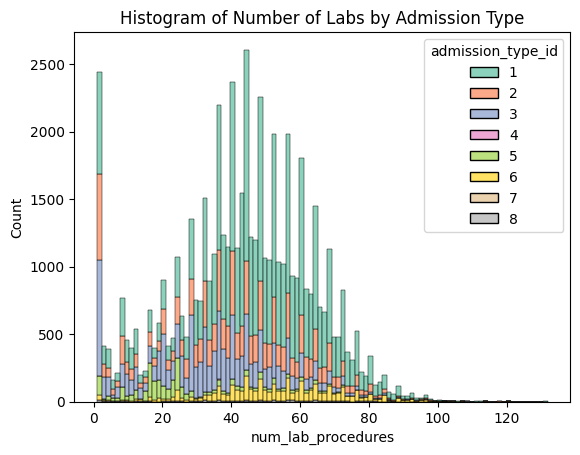

In [20]:
sns.histplot(X_train,
             x="num_lab_procedures",
             hue="admission_type_id",
             multiple='stack',
             palette='Set2')
plt.title("Histogram of Number of Labs by Admission Type")
plt.show()

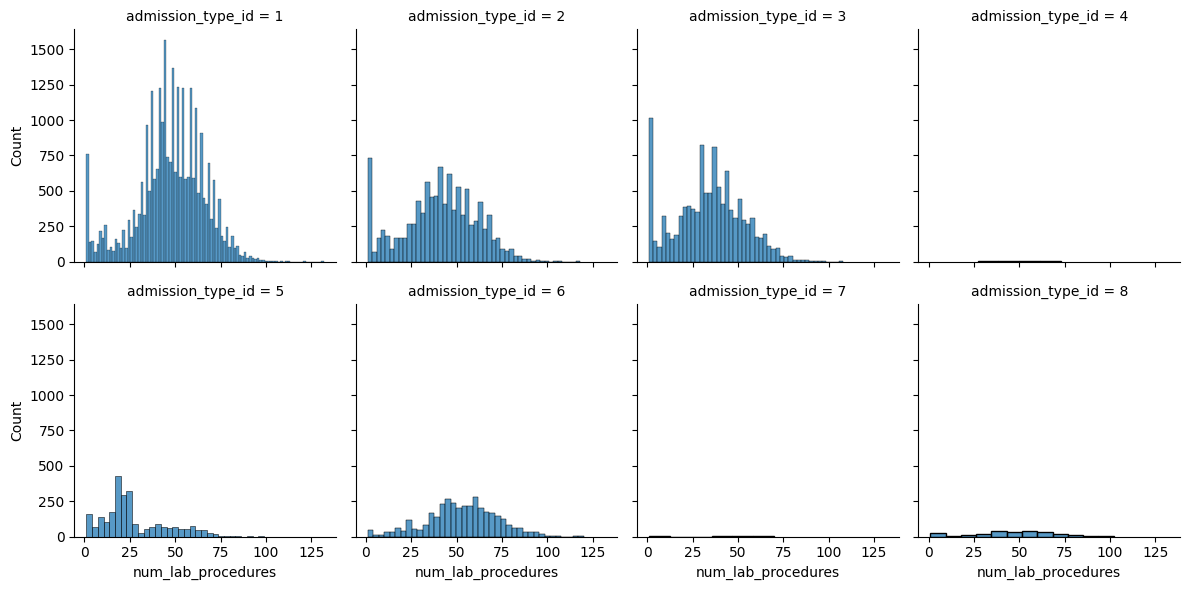

In [21]:
num_labs_grid = sns.FacetGrid(X_train, col_wrap=4, col='admission_type_id')
num_labs_grid.map_dataframe(sns.histplot, x='num_lab_procedures')
plt.show()

# Understanding the Target

#### Class Balance
~11% of observations are of the primary target variable of readmitted within 30 days

#### Relationships to A Select Subset of Features
- Readmission rates are slightly higher in patients with diabetesMed, insulin, metformin
- Mixed impact of admission source on readimission
- Numeric features tend to be positively associated with readmission rates (higher value = higher readmission rate)

In [22]:
# Class Balance
y_train.readmitted.value_counts(normalize=True).round(4)

readmitted
NO     0.5987
>30    0.3117
<30    0.0896
Name: proportion, dtype: float64

In [23]:
# Looking at the readmission rate across features
for f in ['diabetesMed', 'insulin', 'metformin', 'admission_type_id', 'admission_source_id']:
    f_ct = pd.crosstab(X_train[f], y_train['readmitted'])
    print(f_ct.apply(lambda x: x / sum(x), axis=0))

readmitted        <30       >30        NO
diabetesMed                              
No           0.202379  0.208333  0.263305
Yes          0.797621  0.791667  0.736695
readmitted       <30       >30        NO
insulin                                 
Down        0.125756  0.113336  0.097889
No          0.449795  0.473306  0.500744
Steady      0.319750  0.308042  0.310075
Up          0.104699  0.105316  0.091291
readmitted       <30       >30        NO
metformin                               
Down        0.007409  0.005440  0.005926
No          0.804835  0.797218  0.785537
Steady      0.178787  0.186014  0.196333
Up          0.008969  0.011328  0.012203
readmitted              <30       >30        NO
admission_type_id                              
1                  0.517645  0.513403  0.510437
2                  0.179957  0.182705  0.181094
3                  0.180542  0.168293  0.209383
4                  0.000195  0.000112  0.000117
5                  0.043673  0.048228  0.042828
6   

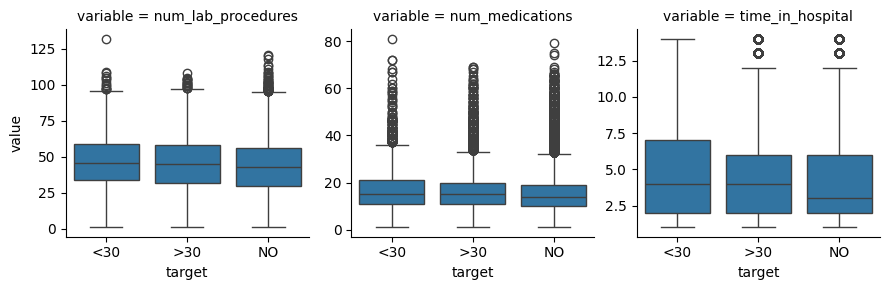

In [24]:
plotting_df = X_train.loc[:, ['num_lab_procedures', 'num_medications', 'time_in_hospital']]
plotting_df['target'] = y_train['readmitted']

long_plot_df = plotting_df.melt(id_vars='target')

# Creating a grid to see the relationships between the features and the target
target_grid = sns.FacetGrid(long_plot_df, col_wrap=3, col='variable', sharey=False)
target_grid.map_dataframe(sns.boxplot, x='target', y='value')
plt.show()